In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

#import mnist
from torchvision.datasets import MNIST

from Autoencoders import Autoencoder
from helper import load_optimizer_and_scheduler, save_optimizer_and_scheduler

random_state = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


/home/maxheise/anaconda3/envs/ML/lib/python3.13/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # (16, 14, 14)
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  # (32, 7, 7)
            nn.ReLU(True),
            nn.Conv2d(32, 64, 7)  # (64, 1, 1)
        )
    
    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 7),  # (32, 7, 7)
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),  # (16, 14, 14)
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),  # (1, 28, 28)
            nn.Sigmoid()
        )
    
    def forward(self, z):
        return self.fc(z)

# class Encoder(nn.Module):
#     def __init__(self, input_dim, latent_dim):
#         super(Encoder, self).__init__()
#         self.fc = nn.Sequential(
#             # nn.Flatten(),
#             nn.Linear(28*28, 256),
#             nn.ReLU(True),
#             nn.Linear(256, 128),
#             nn.ReLU(True),
#             nn.Linear(128, 64),
#             nn.ReLU(True),
#             nn.Linear(64, 32)
#         )
    
#     def forward(self, x):
#         return self.fc(x)

# class Decoder(nn.Module):
#     def __init__(self, latent_dim, output_dim):
#         super(Decoder, self).__init__()
#         self.fc = nn.Sequential(
#             nn.Linear(32, 64),
#             nn.ReLU(True),
#             nn.Linear(64, 128),
#             nn.ReLU(True),
#             nn.Linear(128, 256),
#             nn.ReLU(True),
#             nn.Linear(256, 28*28),
#             nn.Sigmoid(),  # For pixel values between 0 and 1
#             # nn.Unflatten(1, (1, 28, 28))
#         )
    
#     def forward(self, z):
#         return self.fc(z)

In [10]:
mnist = MNIST(root='data', train=True, download=True, transform=None)
data, labels = mnist.data, mnist.targets
data = data[labels == 3][:3000]
labels = labels[labels == 3]
data = torch.tensor(data, dtype=torch.float32).to(device)
data = data / 255.0  # Normalize the images to [0, 1]
data = data.view(data.size(0), 1, 28, 28)  # Add channel dimension
mnist_val = MNIST(root='data', train=False, download=True, transform=None)
val_data, val_labels = mnist_val.data, mnist_val.targets
val_data = val_data[val_labels == 3][:1000]
val_labels = val_labels[val_labels == 3]
val_data = torch.tensor(val_data, dtype=torch.float32).to(device)
val_data = val_data / 255.0  # Normalize the images to [0, 1]
val_data = val_data.view(val_data.size(0), 1, 28, 28)  # Add channel dimension

/tmp/ipykernel_35166/3765578967.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data, dtype=torch.float32).to(device)
/tmp/ipykernel_35166/3765578967.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_data = torch.tensor(val_data, dtype=torch.float32).to(device)


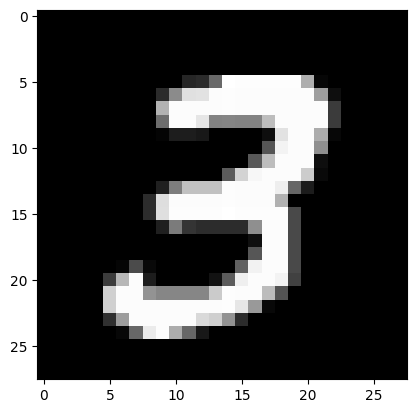

In [13]:
plt.imshow(data[0, 0].cpu().numpy(), cmap='gray')
plt.show()

In [14]:
# define model parameters
latent_dim = 32
input_dim = data.shape[1]
output_dim = data.shape[1]
batch_size = 256

train_dataloader = DataLoader(data, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

# model_path = "models/conformal_autoencoder_half_sphere.pth"
# optimizer_path = "models/conformal_autoencoder_half_sphere_optimizer.pth"

In [16]:
encoder = Encoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
decoder = Decoder(latent_dim=latent_dim, output_dim=output_dim).to(device)
conformal_autoencoder = Autoencoder(encoder, decoder).to(device)
optmizer, scheduler = conformal_autoencoder.train_model(train_dataloader, val_dataloader, batch_size=batch_size, epochs=1000, learning_rate=0.001, log_every=100, val_every=100, scheduler_kwargs={"step_size": 100, "gamma": 0.5})

Epoch [100/1000], Loss: 0.00354952
Epoch [100/1000], Validation Loss: 0.00462735
Epoch [200/1000], Loss: 0.00256476
Epoch [200/1000], Validation Loss: 0.00386190
Epoch [300/1000], Loss: 0.00222733
Epoch [300/1000], Validation Loss: 0.00359838
Epoch [400/1000], Loss: 0.00207594
Epoch [400/1000], Validation Loss: 0.00349506
Epoch [500/1000], Loss: 0.00199611
Epoch [500/1000], Validation Loss: 0.00344018
Epoch [600/1000], Loss: 0.00195761
Epoch [600/1000], Validation Loss: 0.00341572
Epoch [700/1000], Loss: 0.00193534
Epoch [700/1000], Validation Loss: 0.00340215
Epoch [800/1000], Loss: 0.00192632
Epoch [800/1000], Validation Loss: 0.00339403
Epoch [900/1000], Loss: 0.00192101
Epoch [900/1000], Validation Loss: 0.00339093
Epoch [1000/1000], Loss: 0.00191670
Epoch [1000/1000], Validation Loss: 0.00338887


In [ ]:
model_path = "models/autoencoder_mnist.pth"
optimizer_path = "models/autoencoder_mnist_optimizer.pth"
conformal_autoencoder.save_checkpoint(model_path)
save_optimizer_and_scheduler(optimizer_path, optmizer, scheduler)

Checkpoint saved to models/conformal_autoencoder_half_sphere.pth at epoch 1001
Optimizer and scheduler saved to models/conformal_autoencoder_half_sphere_optimizer.pth


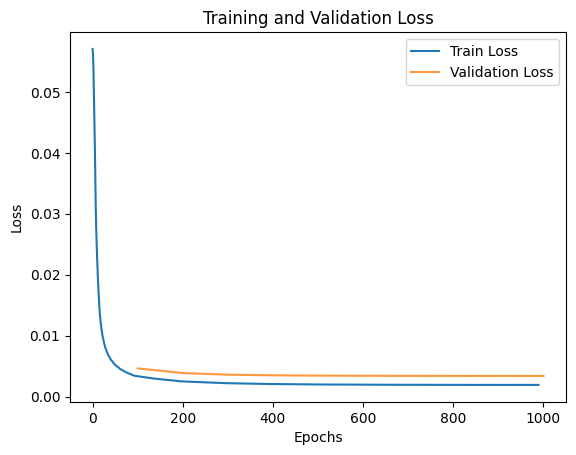

In [17]:
plt.plot(conformal_autoencoder.loss_list[10:], label='Train Loss')
plt.plot(np.linspace(100, 1000, 10), conformal_autoencoder.val_loss_list, alpha=0.8, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

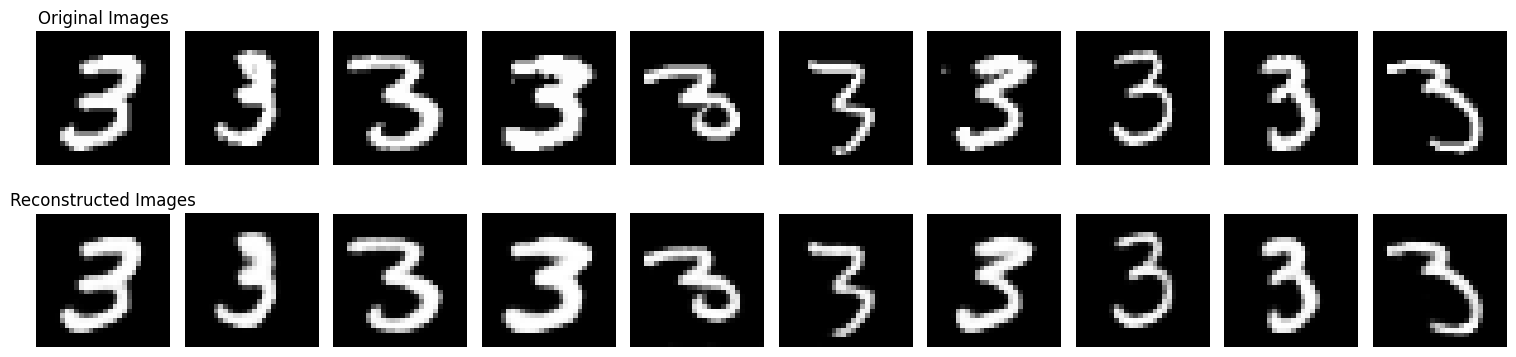

In [18]:
#Encode the data
encoded_data = conformal_autoencoder.encode(data)
# Decode the data
decoded_data = conformal_autoencoder.decode(encoded_data).cpu().detach()
encoded_data = encoded_data.cpu().detach()

# Plot the original and reconstructed images
n_images = 10
fig, axes = plt.subplots(2, n_images, figsize=(15, 4))
for i in range(n_images):
    axes[0, i].imshow(data[i].view(28, 28).cpu().numpy(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(decoded_data[i].view(28, 28).cpu().numpy(), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_title('Original Images')
axes[1, 0].set_title('Reconstructed Images')
plt.tight_layout()
plt.show()

In [19]:
num = 100
J = torch.zeros((num, 32, 32))
for i in range(num):
    latent = encoder(data[i:i+1])
    jac = torch.autograd.functional.jacobian(decoder, latent)
    jac = jac[0,:,0,:]
    J[i] = jac.T @ jac
print(J.mean(dim=0))
print(J.std(dim=0))
print(torch.diag(J.mean(dim=0)))
print(torch.mean(J))

/tmp/ipykernel_35166/2881470352.py:7: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4413.)
  J[i] = jac.T @ jac


RuntimeError: expand(torch.FloatTensor{[28, 64, 64, 28, 1]}, size=[32, 32]): the number of sizes provided (2) must be greater or equal to the number of dimensions in the tensor (5)

ValueError: x and y can be no greater than 2D, but have shapes (1000, 1, 1) and (1000, 1, 1)

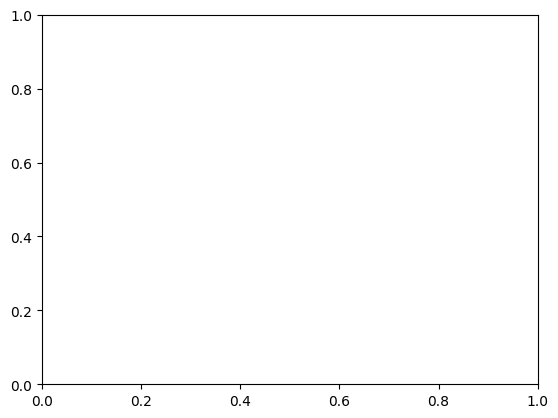

In [20]:
plt.plot(encoded_data[:1000, 0].cpu().numpy(), encoded_data[:1000, 1].cpu().numpy(), 'o', markersize=2)
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Latent Space Representation')
plt.show()

In [12]:
# Load the model and optimizer from checkpoint
encoder = Encoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
decoder = Decoder(latent_dim=latent_dim, output_dim=output_dim).to(device)
autoencoder = ConformalAutoencoder(encoder, decoder).load_model_from_checkpoint(model_path).to(device)
optimizer = autoencoder.get_default_optimizer()
scheduler = autoencoder.get_default_scheduler(optimizer)
optimizer, scheduler = load_optimizer_and_scheduler(optimizer_path, optimizer, scheduler)

Model and custom variables loaded from models/conformal_autoencoder_half_sphere.pth
Optimizer and scheduler loaded from models/conformal_autoencoder_half_sphere_optimizer.pth
